# 05 — Backtesting

Walk-forward backtest across all 40 evaluated variants (2 currencies × D1–D4 × 5 holding periods).

**Decision gate:** Out-of-sample Sharpe > 1.0 (target > 1.5) on the test set.

In [1]:
import sys
sys.path.append('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.backtest import run_backtest, run_all_holding_periods, chronological_split, walk_forward
from src.metrics import full_report, sharpe
from pathlib import Path

cfg = yaml.safe_load(open('../config.yaml'))
bt_cfg = cfg['backtest']
HOLDING_PERIODS = bt_cfg['holding_periods']
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
sig_dir = Path('../data/signals')
crypto_dir = Path('../data/crypto')

btc_sigs = pd.read_parquet(sig_dir / 'BTC_signals.parquet')
btc_spot = pd.read_parquet(crypto_dir / 'BTCUSDT_1h.parquet')
btc_ret = np.log(btc_spot['close']).diff().rename('btc_ret')

eth_sigs = pd.read_parquet(sig_dir / 'ETH_signals.parquet')
eth_spot = pd.read_parquet(crypto_dir / 'ETHUSDT_1h.parquet')
eth_ret = np.log(eth_spot['close']).diff().rename('eth_ret')

bt_kwargs = {
    'position_size': bt_cfg['position_size'],
    'commission':    bt_cfg['commission'],
    'slippage':      bt_cfg['slippage'],
    'stop_loss_sigma': bt_cfg['stop_loss_sigma']
}
print('Data loaded. Running 40 evaluated variants...')

Data loaded. Running 40 evaluated variants...


## 1. Full-Sample Results — All Variants

In [3]:
all_results = []

for ccy, sigs, ret in [('BTC', btc_sigs, btc_ret), ('ETH', eth_sigs, eth_ret)]:
    for sig_name in ['D1', 'D2', 'D3', 'D4']:
        sig = sigs[sig_name]
        if (sig != 0).sum() < 10:
            continue
        hp_results = run_all_holding_periods(sig, ret, HOLDING_PERIODS, **bt_kwargs)
        for hp, trades in hp_results.items():
            if trades.empty:
                continue
            train, val, test = chronological_split(trades, bt_cfg['train_ratio'], bt_cfg['val_ratio'])
            report = full_report(test, label=f'{ccy}_{sig_name}_{hp}h', n_strategy_variants=40)
            report['currency'] = ccy
            report['signal'] = sig_name
            report['holding_h'] = hp
            report['n_train'] = len(train)
            report['n_test'] = len(test)
            all_results.append(report)

results_df = pd.DataFrame(all_results).set_index('label')
print(results_df[['currency','signal','holding_h','n_test','sharpe','win_rate','max_drawdown','ann_return']]
      .sort_values('sharpe', ascending=False).head(10).round(3))

           currency signal  holding_h  n_test  sharpe  win_rate  max_drawdown  \
label                                                                           
ETH_D3_24h      ETH     D3         24     182   3.830     0.418        -0.002   
BTC_D2_24h      BTC     D2         24      23   2.179     0.348        -0.002   
ETH_D2_24h      ETH     D2         24      18   1.659     0.278        -0.001   
BTC_D2_1h       BTC     D2          1      23   1.184     0.609        -0.000   
BTC_D2_8h       BTC     D2          8      23   0.577     0.435        -0.001   
ETH_D2_8h       ETH     D2          8      18   0.379     0.444        -0.001   
BTC_D2_4h       BTC     D2          4      23   0.184     0.522        -0.001   
BTC_D3_24h      BTC     D3         24     180   0.024     0.344        -0.003   
BTC_D4_8h       BTC     D4          8     111  -0.041     0.468        -0.002   
ETH_D2_2h       ETH     D2          2      18  -0.057     0.444        -0.001   

            ann_return  
la

## 2. Equity Curves — Top Strategies

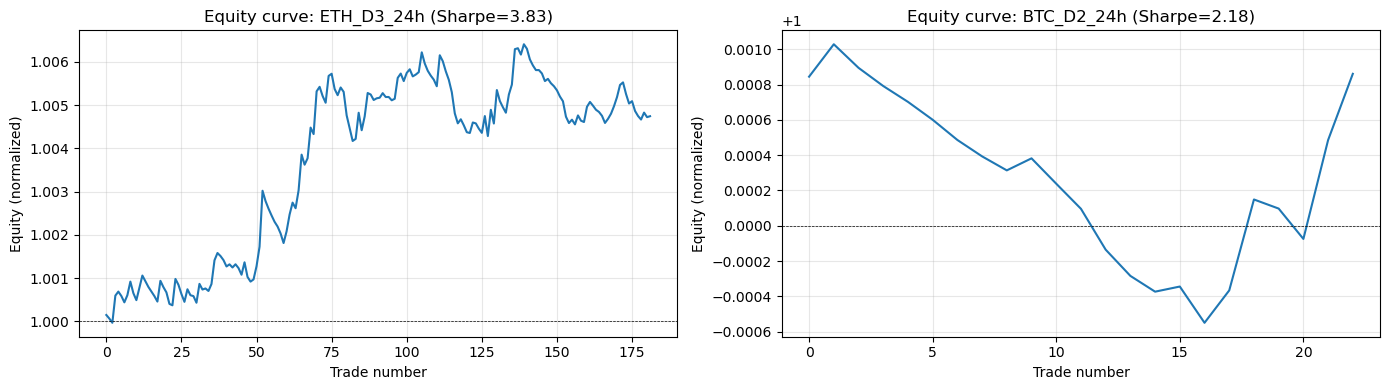

In [4]:
def plot_equity_curve(trades: pd.DataFrame, label: str, ax=None):
    if trades.empty:
        return
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    equity = (1 + trades['net_return'] * trades['position_size']).cumprod()
    ax.plot(range(len(equity)), equity.values, lw=1.5)
    ax.axhline(1, color='black', lw=0.5, ls='--')
    ax.set_xlabel('Trade number')
    ax.set_ylabel('Equity (normalized)')
    ax.set_title(f'Equity curve: {label}')

# Plot top 2 strategies by test Sharpe
top2 = results_df.sort_values('sharpe', ascending=False).head(2)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, row) in zip(axes, top2.iterrows()):
    ccy, sig_name, hp = row['currency'], row['signal'], int(row['holding_h'])
    sigs = btc_sigs if ccy == 'BTC' else eth_sigs
    ret = btc_ret if ccy == 'BTC' else eth_ret
    trades = run_backtest(sigs[sig_name], ret, holding_period=hp, **bt_kwargs)
    _, _, test = chronological_split(trades)
    plot_equity_curve(test, f'{label} (Sharpe={row["sharpe"]:.2f})', ax=ax)

plt.tight_layout()
plt.savefig('../data/plots/equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Walk-Forward Validation — Best Strategy

In [5]:
best = results_df.sort_values('sharpe', ascending=False).iloc[0]
ccy, sig_name, hp = best['currency'], best['signal'], int(best['holding_h'])
sigs = btc_sigs if ccy == 'BTC' else eth_sigs
ret = btc_ret if ccy == 'BTC' else eth_ret

print(f'Running walk-forward for: {ccy} {sig_name} {hp}h holding')
wf_cfg = bt_cfg['walk_forward']

wf_windows = walk_forward(
    sigs[sig_name], ret,
    holding_period=hp,
    train_months=wf_cfg['train_months'],
    test_months=wf_cfg['test_months'],
    gap_days=wf_cfg['gap_days'],
    **bt_kwargs
)

wf_rows = []
for w in wf_windows:
    train_sharpe = sharpe(w['train_trades'])
    test_sharpe = sharpe(w['test_trades'])
    wf_rows.append({
        'window': w['window'],
        'test_start': w['test_start'].strftime('%Y-%m'),
        'train_sharpe': train_sharpe,
        'test_sharpe': test_sharpe,
        'n_test_trades': len(w['test_trades']),
        'is_oos_ratio': test_sharpe / train_sharpe if train_sharpe and train_sharpe != 0 else None
    })

wf_df = pd.DataFrame(wf_rows)
print(wf_df.round(3).to_string(index=False))
print()
print(f'Mean OOS Sharpe: {wf_df["test_sharpe"].mean():.3f}')
print(f'Mean IS/OOS ratio: {wf_df["is_oos_ratio"].mean():.3f} (>0.5 = not overfitting)')

Running walk-forward for: ETH D3 24h holding


 window test_start  train_sharpe  test_sharpe  n_test_trades  is_oos_ratio
      0    2023-01        -0.607        4.549             45        -7.488
      1    2023-04         0.999        3.231             50         3.236
      2    2023-07         0.837       -5.476             56        -6.540
      3    2023-10        -0.041        2.672             58       -64.575
      4    2024-01         0.210        6.513             55        31.032
      5    2024-04         2.151        6.108             50         2.840
      6    2024-07         2.733        2.286             61         0.837
      7    2024-10         4.389       -5.260             57        -1.198
      8    2025-01         2.075       -7.242             55        -3.491
      9    2025-04        -1.462       14.718             52       -10.068
     10    2025-07         0.567        5.460             49         9.629
     11    2025-10         1.767        9.441             49         5.344
     12    2026-01       

## 4. Decision Gate

In [6]:
print('='*60)
print('BACKTEST — DECISION GATE')
print('='*60)

best_oos_sharpe = results_df['sharpe'].max()
gate = best_oos_sharpe > 1.0
target = best_oos_sharpe > 1.5

print(f'Best OOS Sharpe across all 40 evaluated variants: {best_oos_sharpe:.3f}')
print(f'Gate (>1.0): {"✓ PASS" if gate else "✗ FAIL"}')
print(f'Target (>1.5): {"✓ ACHIEVED" if target else "✗ NOT MET"}')
print()
print('Best strategy:', results_df['sharpe'].idxmax())
print('→ PROCEED to Notebook 06 (Cross-Asset)' if gate else '→ No tradeable edge found at this threshold.')

BACKTEST — DECISION GATE
Best OOS Sharpe across all 40 evaluated variants: 3.830
Gate (>1.0): ✓ PASS
Target (>1.5): ✓ ACHIEVED

Best strategy: ETH_D3_24h
→ PROCEED to Notebook 06 (Cross-Asset)
